In [10]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
# loading the data into frame
df = pd.read_csv('pcos_dataset.csv')

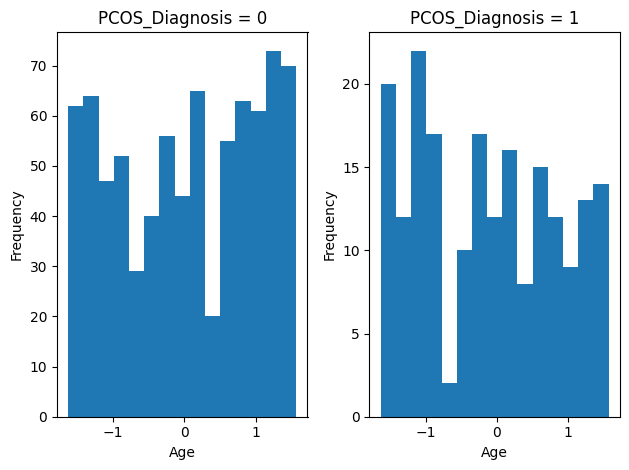

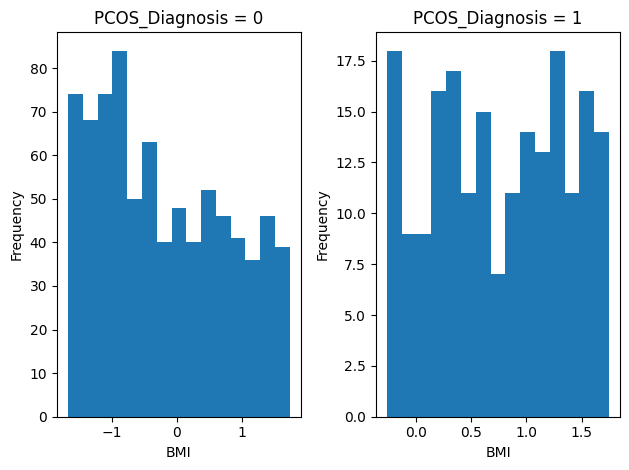

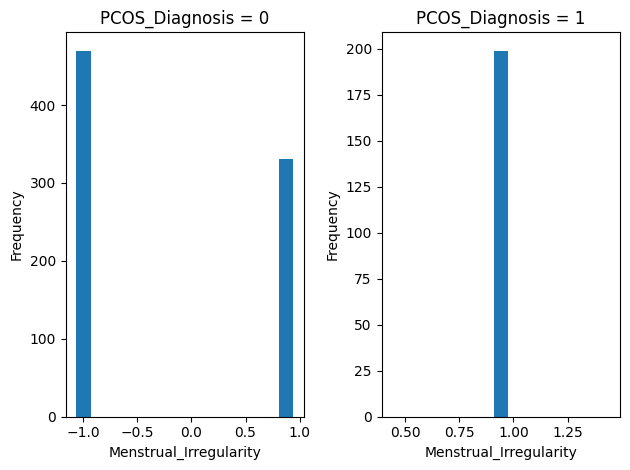

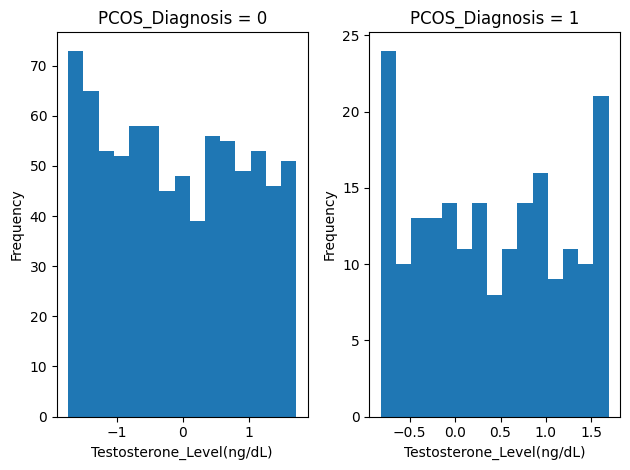

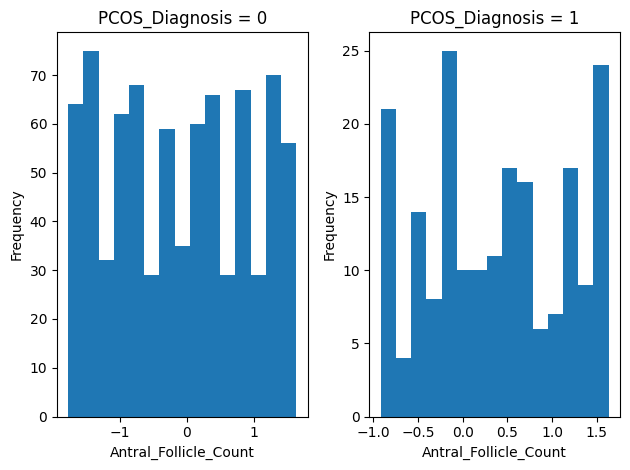

In [12]:
# visualizing before preprocessing (same code as earlier)
target_variable = 'PCOS_Diagnosis'
features = ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count']

# iterating through each feature
for feature in features:
    # separating into class_0 and class_1
    class_0_data = df[df[target_variable] == 0][feature]
    class_1_data = df[df[target_variable] == 1][feature]

    # creating class subplots
    fig, axs = plt.subplots(1, 2, sharey=False, tight_layout=True)

    # plotting histograms
    axs[0].hist(class_0_data, bins=15)
    axs[0].set_title('PCOS_Diagnosis = 0')
    axs[0].set_xlabel(feature)
    axs[0].set_ylabel('Frequency')

    axs[1].hist(class_1_data, bins=15)
    axs[1].set_title('PCOS_Diagnosis = 1')
    axs[1].set_xlabel(feature)
    axs[1].set_ylabel('Frequency')

    plt.show()


In [13]:
# scaling all data
scaler = StandardScaler()
features = ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count']

scaled_data = scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

df[features] = scaled_df[features]
df.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,-0.918642,1.685157,0.941697,-1.510220,0.358206,0
1,0.618141,0.002635,-1.061913,-0.132168,1.065844,0
2,0.027071,-0.564962,-1.061913,1.405721,1.490426,0
3,-0.445785,0.489148,-1.061913,0.127027,1.207371,0
4,-0.800428,-0.869033,0.941697,-0.015530,-1.340124,0


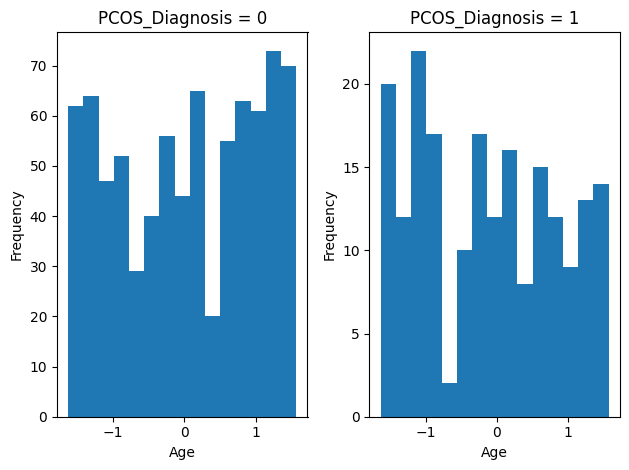

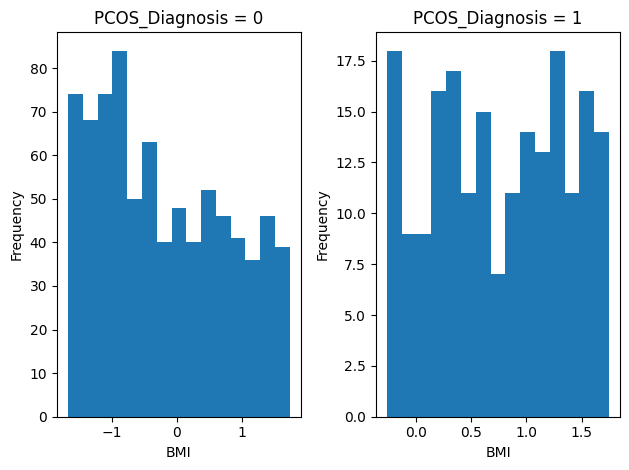

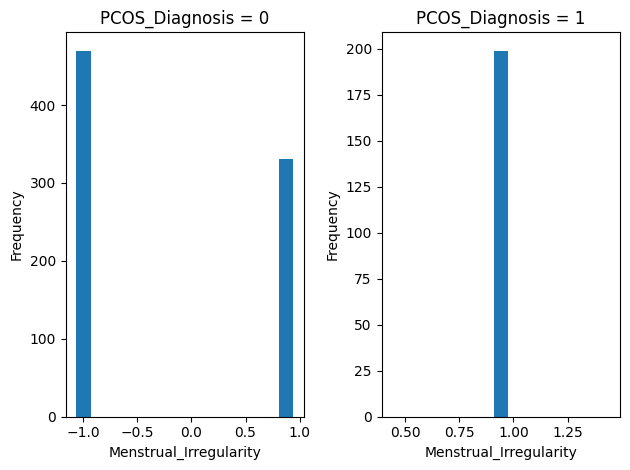

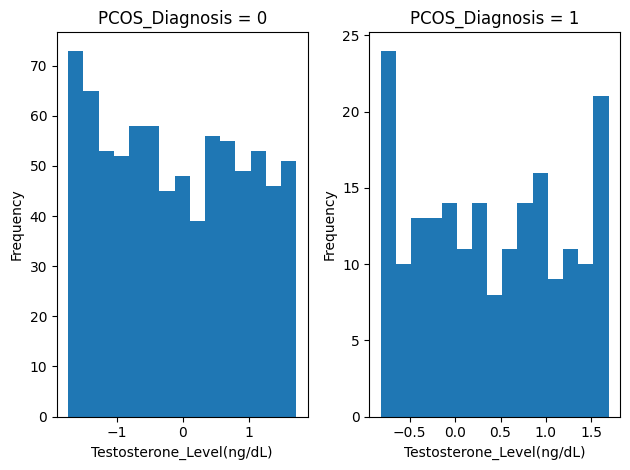

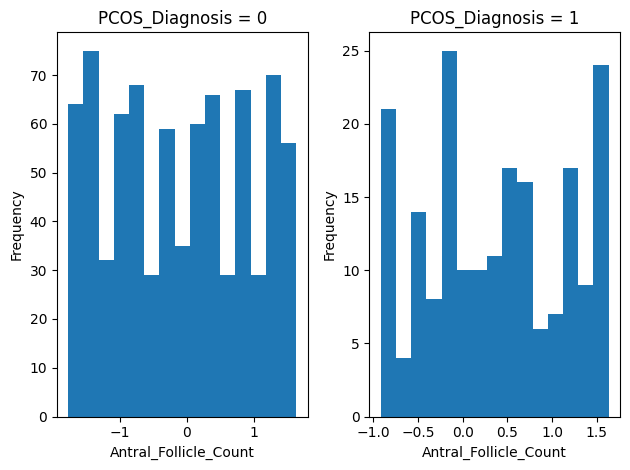

In [14]:
# visualizing after preprocessing
target_variable = 'PCOS_Diagnosis'
features = ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count']

# iterating through each feature
for feature in features:
    # separating into class_0 and class_1
    class_0_data = df[df[target_variable] == 0][feature]
    class_1_data = df[df[target_variable] == 1][feature]

    # creating class subplots
    fig, axs = plt.subplots(1, 2, sharey=False, tight_layout=True)

    # plotting histograms
    axs[0].hist(class_0_data, bins=15)
    axs[0].set_title('PCOS_Diagnosis = 0')
    axs[0].set_xlabel(feature)
    axs[0].set_ylabel('Frequency')

    axs[1].hist(class_1_data, bins=15)
    axs[1].set_title('PCOS_Diagnosis = 1')
    axs[1].set_xlabel(feature)
    axs[1].set_ylabel('Frequency')

    plt.show()

In [8]:
# checking for multicolinearity
# Create a new dataframe with only the selected features
X = df[features]

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF values
print(vif_data)

                     feature       VIF
0                        Age  1.006632
1                        BMI  1.004471
2     Menstrual_Irregularity  1.005248
3  Testosterone_Level(ng/dL)  1.004628
4      Antral_Follicle_Count  1.002630


In [15]:
# all of the VIF values are incredibly close to 1, meaning that there is no correlation

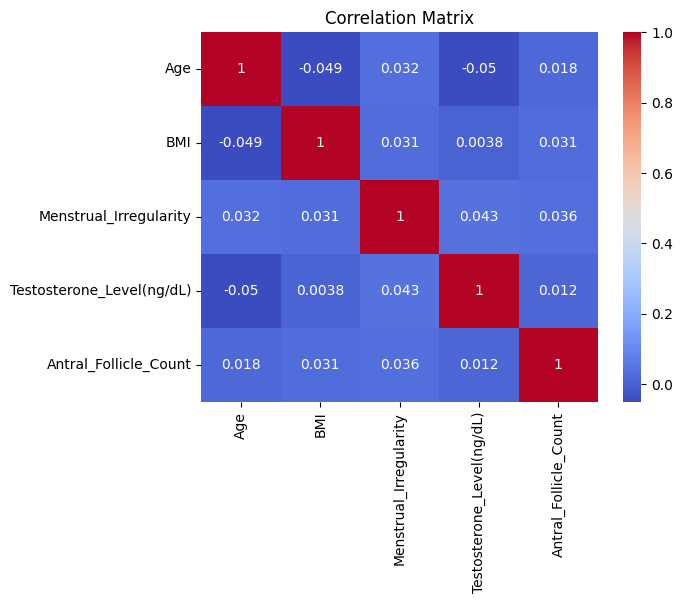

In [11]:
#visualizing feature correlations
corr_matrix = df[features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [18]:
# using the matrix, there is no multicolinearity visually - just an overall nothing-burger dataset :/